**WEEK 3 : To Develop a Customer Intelligence System using Classification, Ensemble and Clustering**




Dataset used : Country Data (Unsupervised Learning on Country Data)
Link : https://www.google.com/url?q=https%3A%2F%2Fwww.kaggle.com%2Fdatasets%2Frohan0301%2Funsupervised-learning-on-country-data

**1] Importing all neccessary libraires**

In [224]:
#importing all neccessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans,DBSCAN
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import train_test_split

**2] To upload the dataset**

In [225]:
df=pd.read_csv('/content/Country-data.csv')
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [226]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [227]:
print("Rows and Columns: ",df.shape)
print(df.columns)

Rows and Columns:  (167, 10)
Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')


**3] Data Cleaning**

We clean the data by : stripping whitespaces from column names, dropping duplicate rows, force all relevant columns to numeric type and impute any missing values using the median of each column (median is preferred over mean because it is less affected by outliers)

In [228]:
df.columns=df.columns.str.strip()
print('Columns after stripping whitespace: ')
print(df.columns.tolist())

#Dropping duplicate rows
df.duplicated().sum()
df=df.drop_duplicates()
print("After dropping duplicates: ",df.shape)

#Forcing numeric types on all columns except country name
numeric_cols=df.columns.drop('country')
for col in numeric_cols:
  df[col]=pd.to_numeric(df[col],errors='coerce')
print('Data types after conversion: ')
print(df.dtypes)


#Checking for missing values
print('Missing values before imputation: ')
print(df.isnull().sum())
for col in numeric_cols:
  median_value=df[col].median()
  df[col]=df[col].fillna(median_value)
print('\nMissing values afer imputation: ')
print(df.isnull().sum())

Columns after stripping whitespace: 
['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
After dropping duplicates:  (167, 10)
Data types after conversion: 
country        object
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object
Missing values before imputation: 
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Missing values afer imputation: 
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


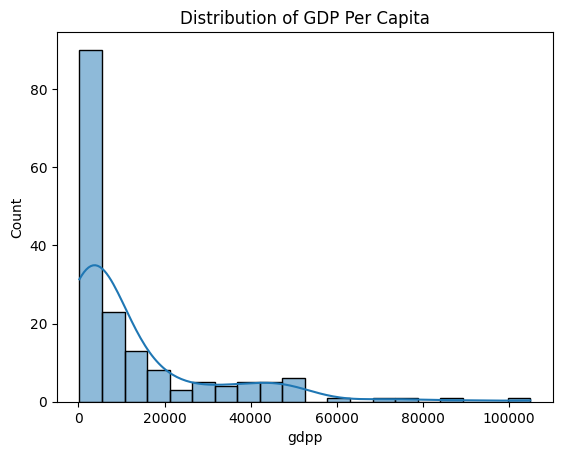

In [229]:
#Exploratory Data Analysis
sns.histplot(df["gdpp"],bins=20,kde=True)
plt.title("Distribution of GDP Per Capita")
plt.show()

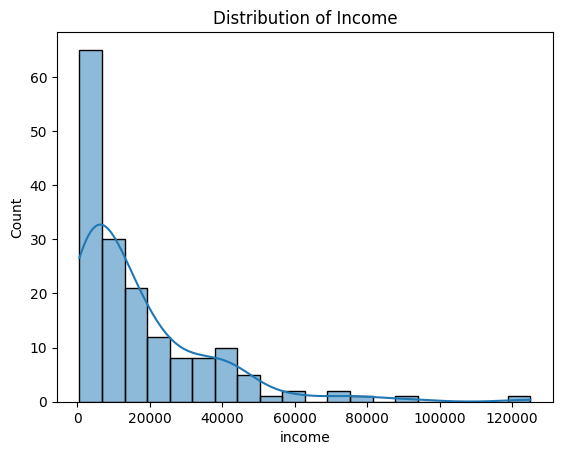

In [230]:
sns.histplot(df["income"],bins=20,kde=True)
plt.title("Distribution of Income")
plt.show()

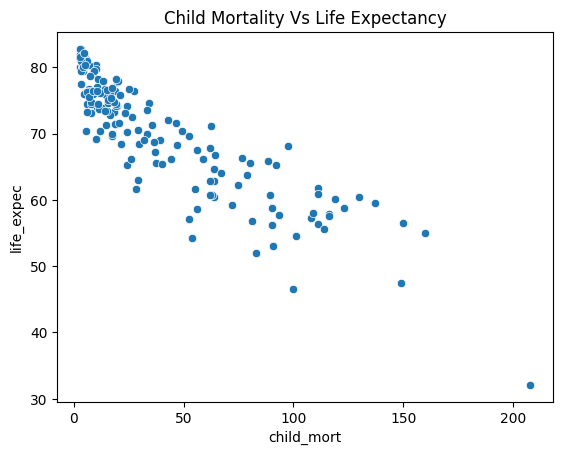

In [231]:
sns.scatterplot(x="child_mort",y="life_expec",data=df)
plt.title('Child Mortality Vs Life Expectancy')
plt.show()

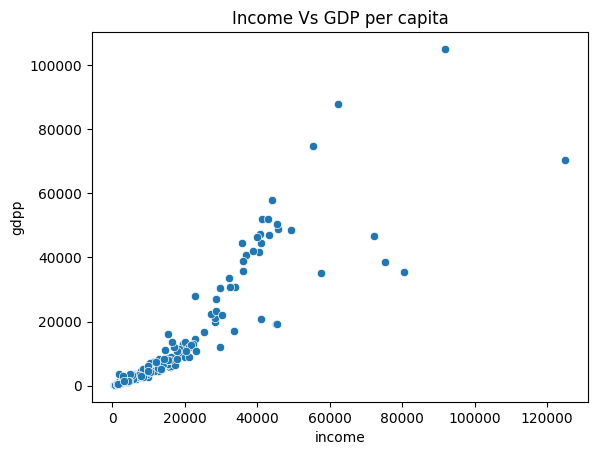

In [232]:
sns.scatterplot(x='income',y='gdpp',data=df)
plt.title("Income Vs GDP per capita")
plt.show()

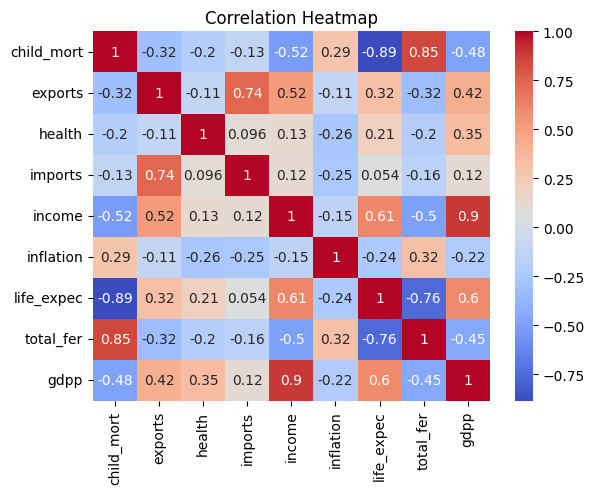

In [233]:
sns.heatmap(df.drop("country",axis=1).corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

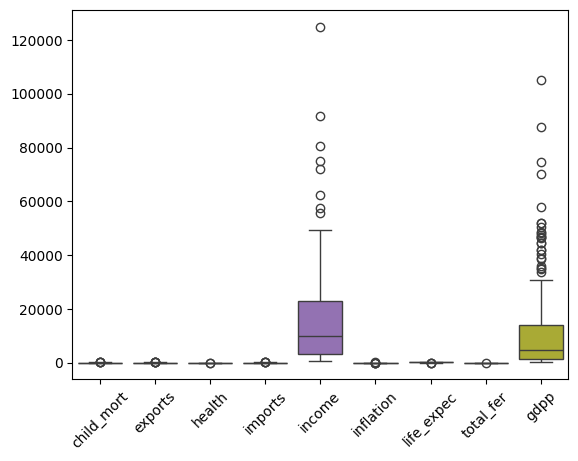

In [234]:
sns.boxplot(data=df.drop("country",axis=1))
plt.xticks(rotation=45)
plt.show()

**4] Feature selection and Scaling**

We separate the country column, keep the continuous numeric features for clustering and scale all features.

In [235]:
country_names=df['country']
features=df.drop(columns=['country'])
print('Features used for clustering: ')
print(features.columns.tolist())
features.head()

#Scaling all features
scaler=StandardScaler()
scaled_features=scaler.fit_transform(features)
scaled_df=pd.DataFrame(scaled_features, columns=features.columns)
scaled_df.head()

Features used for clustering: 
['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


**5] Elbow Method - To find the optimal number of clusters (k)**

We use the elbow method to find a good value of k
In this method: We run K-Means for k=2 to 10. For each k, we record the inertia, then we plot k vs inertia. As k increases, inertia always decreases, but after a certain point the decrease becomes considerably smaller, this plot then looks like an 'elbow' and gives an estimate of the optimal k.

In [236]:
inertia_values=[]
k_range=range(2,11)
for k in k_range:
  kmeans_model=KMeans(n_clusters=k,random_state=42,n_init=10)
  kmeans_model.fit(scaled_features)
  inertia_values.append(kmeans_model.inertia_)
print('Inertia Values for k=2 to 10: ')
for k, inertia in zip(k_range,inertia_values):
  print(f'k={k}->inertia={inertia:.2f}')

Inertia Values for k=2 to 10: 
k=2->inertia=1050.21
k=3->inertia=831.42
k=4->inertia=700.52
k=5->inertia=620.16
k=6->inertia=558.47
k=7->inertia=495.81
k=8->inertia=457.59
k=9->inertia=427.80
k=10->inertia=403.23


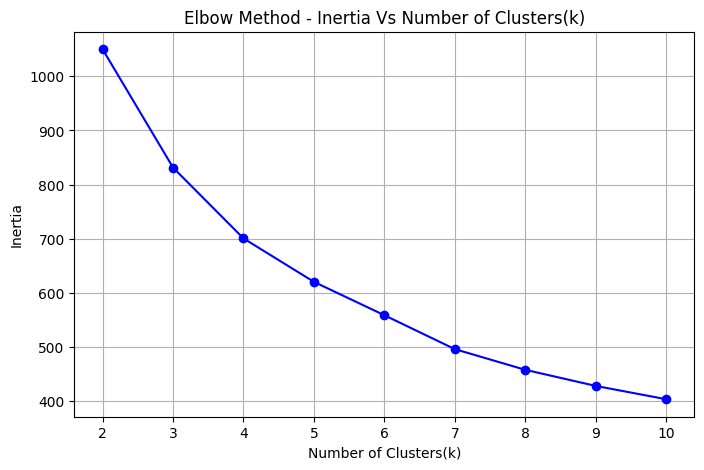

In [237]:
plt.figure(figsize=(8,5))
plt.plot(list(k_range),inertia_values,marker='o',linestyle='-',color='b')
plt.title('Elbow Method - Inertia Vs Number of Clusters(k)')
plt.xlabel('Number of Clusters(k)')
plt.ylabel('Inertia')
plt.xticks(list(k_range))
plt.grid(True)
plt.show()

**Observation:**
Looking at the curve, the rate of decrease in inertia slows down around k=3. Hence, we choose k=3 as our baseline number of clusters.

In [238]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df.drop("country",axis=1))

In [239]:
kmeans=KMeans(n_clusters=3, random_state=42)
df["KMeans_Cluster"]=kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"].value_counts()
cluster_summary=df.groupby("KMeans_Cluster").mean(numeric_only=True)
cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,22.456977,40.273128,6.251047,47.362394,12321.744186,7.720884,72.566279,2.340349,6461.767442
1,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
2,95.106667,28.602444,6.301111,42.306667,3539.844444,11.986778,59.055556,5.065333,1766.711111


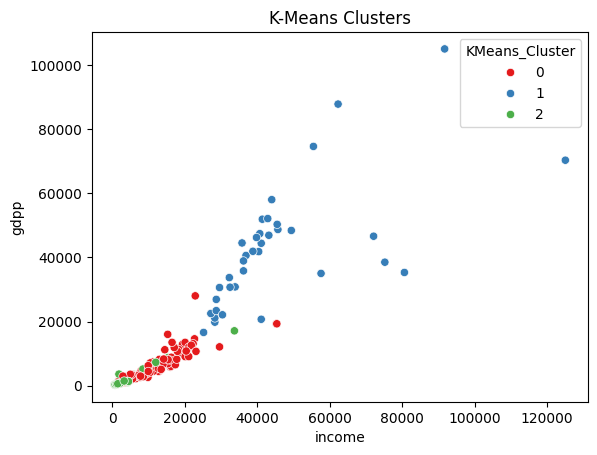

In [240]:
sns.scatterplot(x="income",y="gdpp",hue="KMeans_Cluster",data=df,palette="Set1")
plt.title("K-Means Clusters")
plt.show()

**6] Training the K-Means Model with best_k=3**



In [241]:
best_k=3
kmeans=KMeans(n_clusters=best_k,random_state=42,n_init=10)
kmeans_labels=kmeans.fit_predict(scaled_features)
df['KMeans_Cluster']=kmeans_labels
y=df['KMeans_Cluster']
X_classification=X_scaled
print('K-means model trained with best_k= ',best_k)
print('\nNumber of countries in each cluster: ')
print(df['KMeans_Cluster'].value_counts())

K-means model trained with best_k=  3

Number of countries in each cluster: 
KMeans_Cluster
2    84
1    47
0    36
Name: count, dtype: int64


**Prepare Data for Classification**

In [242]:
X_train,X_test,y_train,y_test=train_test_split(X_classification,y,test_size=0.2,random_state=42,stratify=y)
print("Training samples: ",X_train.shape[0])
print("Testing samples: ",X_test.shape[0])

Training samples:  133
Testing samples:  34


**7] Evaluating Clustering with Silhouette Score**

The silhoutte score measures how well-separated and well-defined the clusters are. It ranges from -1 and +1.
>A score close to +1 indicates points are well-matched, a score close to 0 means overlapping and negative score means points may be assigned to wrong cluster.

In [243]:
sil_score=silhouette_score(scaled_features,kmeans_labels)
print(f'Silhouette score for K-Means (k={best_k}): {sil_score:.4f}')


Silhouette score for K-Means (k=3): 0.2833


**8] DBSCAN : Second Clustering Approach**

DBSCAN groups together points that are closely packed and marks points in low density regions as noise/outliers. It does not require specifying the number of clusters beforehand and needs two parameters: eps and min_samples.

In [244]:
dbscan=DBSCAN(eps=1.5,min_samples=5)
dbscan_labels=dbscan.fit_predict(scaled_features)
df['DBSCAN_Cluster']=dbscan_labels
print('DBSCAN cluster distribution (-1 means noise/outlier points): ')
print(df['DBSCAN_Cluster'].value_counts())
n_clusters_dbscan=len(set(dbscan_labels))-(1 if -1 in dbscan_labels else 0)
n_noise=list(dbscan_labels).count(-1)
print(f'Number of clusters found by DBSCAN: {n_clusters_dbscan}')
print(f'Number of noise points: {n_noise}')

DBSCAN cluster distribution (-1 means noise/outlier points): 
DBSCAN_Cluster
 0    137
-1     30
Name: count, dtype: int64
Number of clusters found by DBSCAN: 1
Number of noise points: 30


>Comparing K-Means and DBSCAN we note that unlike K-Means, DBSCAN found its own number of clusters and identified noise. This shows the difference between partition based and a density based method.

**9] PCA Visualization of K-Means Clusters**

PCA is a dimensionality reduction technique that compresses data into fewer dimensions, while retaining as much of the original variance as possible.

Explained variance ratio by the 2 principal components: 
[0.4595174  0.17181626]
Total varinace captured by the 2 components: 63.13%


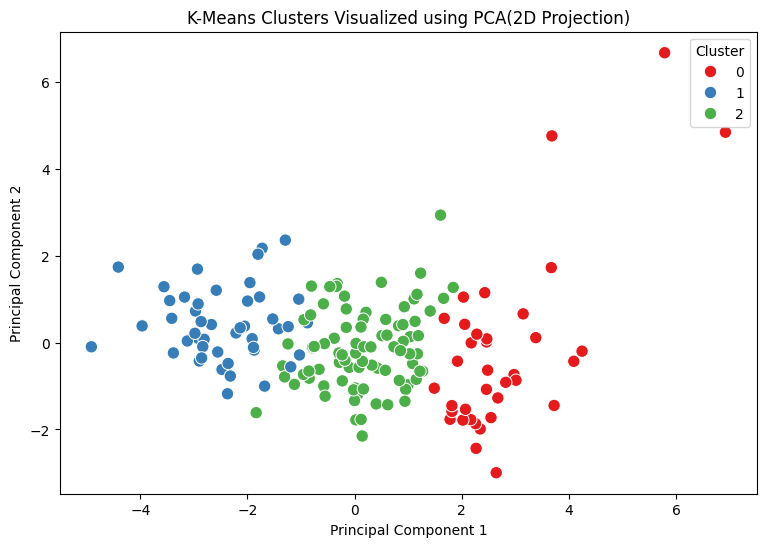

In [245]:
pca=PCA(n_components=2,random_state=42)
pca_components=pca.fit_transform(scaled_features)
df['PCA1']=pca_components[:,0]
df['PCA2']=pca_components[:,1]
print('Explained variance ratio by the 2 principal components: ')
print(pca.explained_variance_ratio_)
print('Total varinace captured by the 2 components: {:.2f}%'.format(pca.explained_variance_ratio_.sum()*100))

plt.figure(figsize=(9,6))
scatter=sns.scatterplot(x='PCA1',y='PCA2',hue='KMeans_Cluster',palette='Set1',data=df,s=80,legend='full')
plt.title('K-Means Clusters Visualized using PCA(2D Projection)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.show()

**10] Logistic Regression**

In [246]:
lr=LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
lr_pred=lr.predict(X_test)
lr_accuracy=accuracy_score(y_test,lr_pred)
print(classification_report(y_test,lr_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



**11] Decision Tree**

In [247]:
#Decision Tree Classifier
dt_model=DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)
dt_predictions=dt_model.predict(X_test)
dt_accuracy=accuracy_score(y_test,dt_predictions)
print("Decision Tree Accuracy: ",round(dt_accuracy,4))
print("\nClassification Report: \n")
print(classification_report(y_test,dt_predictions))

Decision Tree Accuracy:  0.9412

Classification Report: 

              precision    recall  f1-score   support

           0       0.88      1.00      0.93         7
           1       1.00      0.90      0.95        10
           2       0.94      0.94      0.94        17

    accuracy                           0.94        34
   macro avg       0.94      0.95      0.94        34
weighted avg       0.94      0.94      0.94        34



**12] Random Forest**

In [248]:
#Random Forest Classification
rf_model=RandomForestClassifier(n_estimators=100,random_state=42)
rf_model.fit(X_train,y_train)
rf_predictions=rf_model.predict(X_test)
rf_accuracy=accuracy_score(y_test,rf_predictions)
print("Random Forest Accuracy: ",round(rf_accuracy,4))
print("\nClassification Report: \n")
print(classification_report(y_test,rf_predictions))

Random Forest Accuracy:  1.0

Classification Report: 

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        17

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



**13] XGBoost**

In [249]:
#XGBoost Classification
xgb_model=XGBClassifier(random_state=42,eval_metric="mlogloss",use_label_encoder=False)
xgb_model.fit(X_train,y_train)
xgb_predictions=xgb_model.predict(X_test)
xgb_accuracy=accuracy_score(y_test,xgb_predictions)
print("XGBoost Accuracy: ",round(xgb_accuracy,4))
print("\nClassification Report:\n")
print(classification_report(y_test,xgb_predictions))

XGBoost Accuracy:  0.9412

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       1.00      0.90      0.95        10
           2       0.89      1.00      0.94        17

    accuracy                           0.94        34
   macro avg       0.96      0.92      0.94        34
weighted avg       0.95      0.94      0.94        34



/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [04:26:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


**14] MODEL COMPARISON**


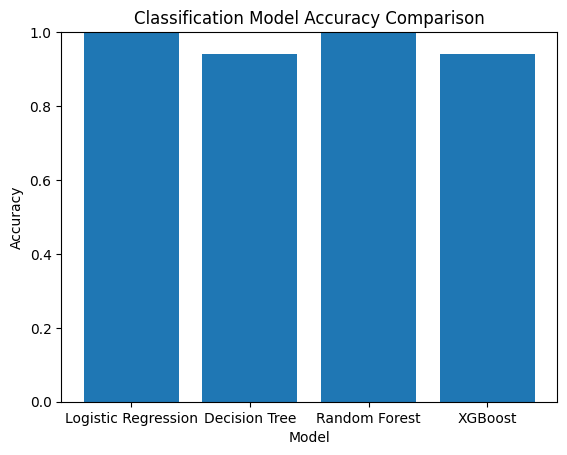

In [250]:
comparison={"Model":["Logistic Regression","Decision Tree","Random Forest","XGBoost"],"Accuracy":[lr_accuracy,dt_accuracy,rf_accuracy,xgb_accuracy]}
comparison_df=pd.DataFrame(comparison)


plt.bar(comparison_df["Model"],comparison_df["Accuracy"])
plt.title("Classification Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

**15] Inspecting Cluster Characteristics**

To understand the meaning of each cluster we look at the average values of each feature within every K-Means cluster.

In [251]:
cluster_summary=df.groupby('KMeans_Cluster')[features.columns].mean()
cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
KMeans_Cluster,,,,,,,,,
0,5.000000,58.738889,8.807778,51.491667,45672.222222,2.671250,80.127778,1.752778,42494.444444
1,92.961702,29.151277,6.388511,42.323404,3942.404255,12.019681,59.187234,5.008085,1922.382979
2,21.927381,40.243917,6.200952,47.473404,12305.595238,7.600905,72.814286,2.307500,6486.452381


**16] Countries in each cluster**

In [252]:
for cluster_id in sorted(df['KMeans_Cluster'].unique()):
  countries_in_cluster=df[df['KMeans_Cluster']==cluster_id]['country'].tolist()
  print(f'\nCluster {cluster_id}({len(countries_in_cluster)}countries):')
  print(countries_in_cluster[:10],'...' if len(countries_in_cluster)>10 else '')


Cluster 0(36countries):
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland'] ...

Cluster 1(47countries):
['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros'] ...

Cluster 2(84countries):
['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bangladesh', 'Barbados', 'Belarus'] ...


**17] Visualization Of Key Features per Cluster**

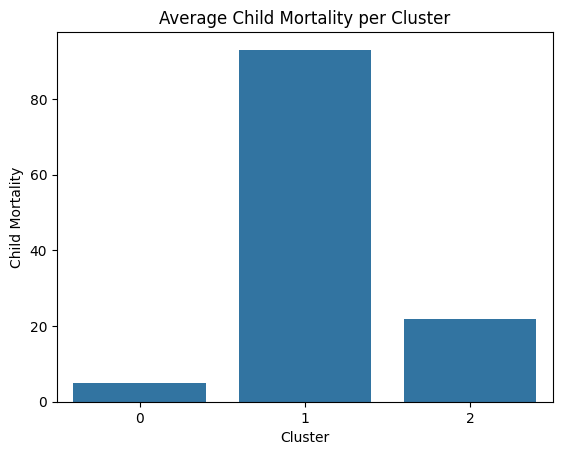

In [253]:
sns.barplot(x=cluster_summary.index,y=cluster_summary['child_mort'])
plt.title('Average Child Mortality per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Child Mortality')
plt.show()

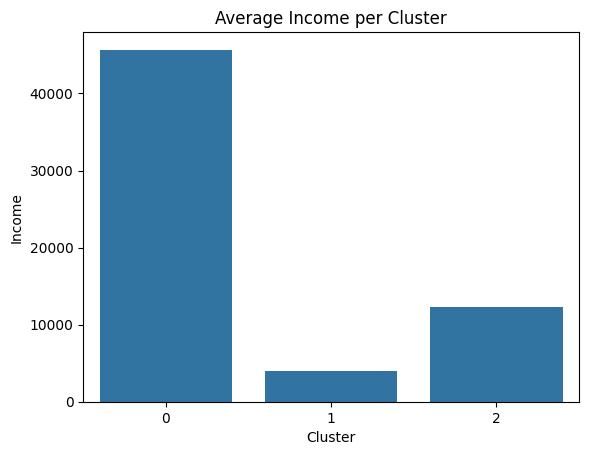

In [254]:
sns.barplot(x=cluster_summary.index,y=cluster_summary['income'])
plt.title('Average Income per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Income')
plt.show()

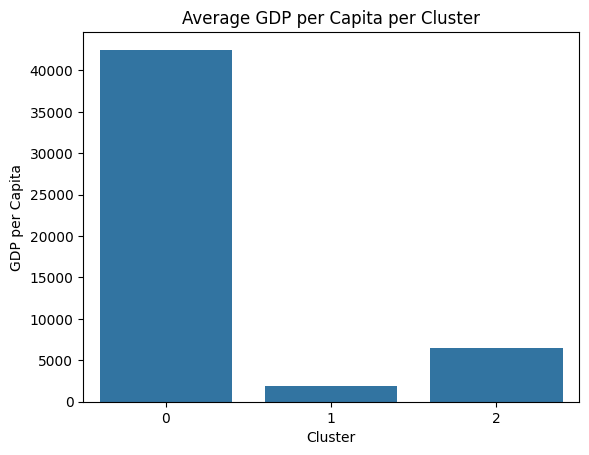

In [255]:
sns.barplot(x=cluster_summary.index,y=cluster_summary['gdpp'])
plt.title('Average GDP per Capita per Cluster')
plt.xlabel('Cluster')
plt.ylabel('GDP per Capita')
plt.show()

**18] Summary of results**



*   We cleaned and scaled the dataset.
*   Using the elbow method, we determined the best possible reasonable number of clusters.


*   We trained a K-Means Model and evaluated the silhouette scpre.
*   We also trained a DBSCAN model as a second density-based clustering approach for comparison.


*  We used PCA to reduce the data to lesser dimensions and visualized the K-Means clusters in a color-coded scatterplot.





**19] Final Observations**

Based on all the visualizations,
1. High-Mortality Cluster: The cluster with the highest average child_mort value also has the lowest average income and gdpp. These are mostly countries from regions facing significant development challenges. This cluster represents countries that are most in need of basic development.
2. Top-tier economic zone: The cluster with the highest income,gdpp and life_expec and the lowest child_mort represents economically developed high income nations.
3. Low development/middle cluster: The remaining cluster is between two extremes -moderate income, moderate child mortality, and moderate GDP per capita. These are developing nations that are progressing but still have room for improvement in healthcare and economic infrastructure.
4. PCA Scatterplot Interpretation: In the PCA scatterplot, the clusters appear as fairly distinct groups along principal component 1, which seems to roughly correspond to an overall 'development level' axis- countries on one end have low income/high mortality and countries on the other end have high income/low mortality with the middle cluster between them.
5. DBSCAN vs K-Means: DBSCAN identified a smaller number of dense clusters and flagged a few countries as noise/outliers- these are likely countires with unusual combination of features that don't fit itno the typical grouping found by K-Means. This shows that K-Means gives us a clean 3-way split useful for decisions, DBSCAN is useful for flagging outlier cases that might need individual attention.